In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
# importing libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [3]:
# transforming the image data
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
print('Successfully Done')

Successfully Done


In [4]:
# loading datasets
train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_path  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=test_path, transform=test_transforms)
print('Successfully Done')

Successfully Done


In [5]:
# creating data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
print('Successfully Done')

Successfully Done


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


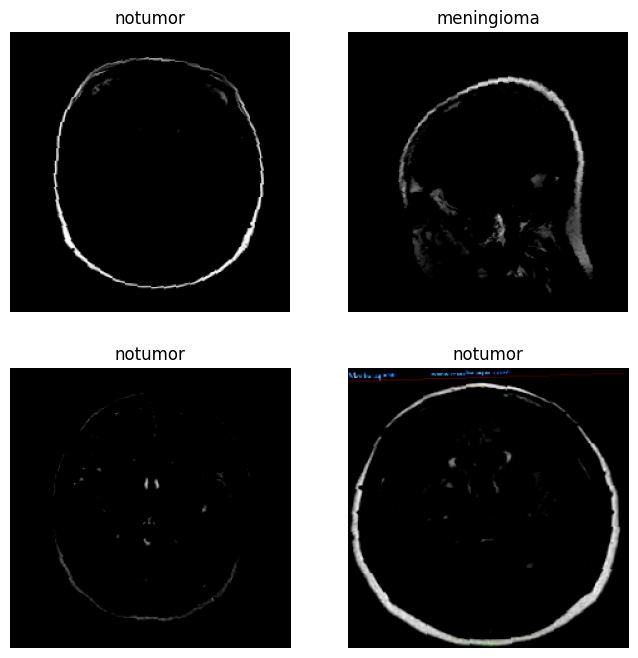

In [6]:
# inspecting the image data
images, labels = next(iter(train_loader))

plt.figure(figsize=(8,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

In [7]:
# Loading the CNN Model (ResNet18)
import torchvision.models as models
import torch.nn as nn

model_resnet = models.resnet18(pretrained=True)

print('Successfully Done')

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]

Successfully Done


In [8]:
# Replacing the final layer
num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, 4)
print('Successfully Done')

Successfully Done


In [9]:
# Finding the loss 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=0.0001)
print(type(criterion))

<class 'torch.nn.modules.loss.CrossEntropyLoss'>


In [10]:
# Assigning to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet.to(device)
print('Successfully Done')

Successfully Done


In [11]:
# Training the model on MRI brain tumor dataset
epochs = 8
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model_resnet.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # reset gradients
        outputs = model_resnet(images) # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")


Epoch [1/8] | Loss: 0.2504 | Accuracy: 90.81%
Epoch [2/8] | Loss: 0.0753 | Accuracy: 97.51%
Epoch [3/8] | Loss: 0.0455 | Accuracy: 98.49%
Epoch [4/8] | Loss: 0.0312 | Accuracy: 98.93%
Epoch [5/8] | Loss: 0.0258 | Accuracy: 99.32%
Epoch [6/8] | Loss: 0.0243 | Accuracy: 99.21%
Epoch [7/8] | Loss: 0.0256 | Accuracy: 99.21%
Epoch [8/8] | Loss: 0.0173 | Accuracy: 99.47%


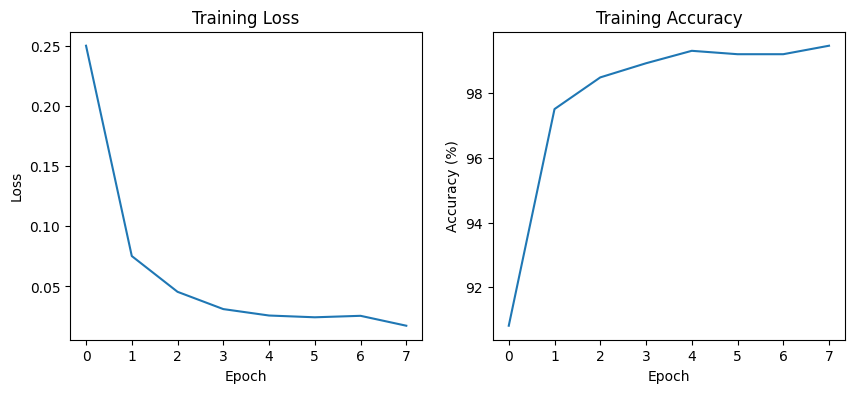

In [12]:
# Ploting the Loss and Accuracy Graphs
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()


In [13]:
# Evaluating the trained model on test dataset
model_resnet.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():  # no backpropagation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_resnet(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 99.24%


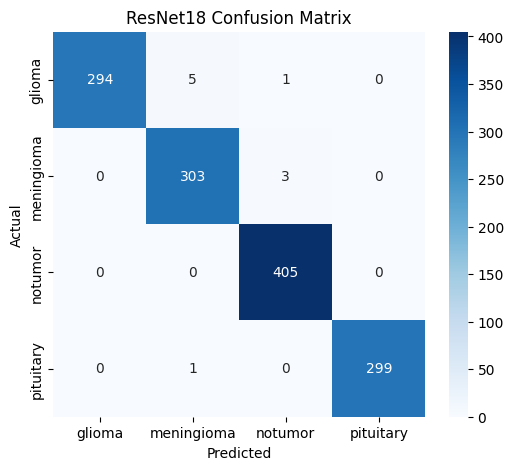

In [14]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 Confusion Matrix")
plt.show()


In [15]:
# Finding precision, recall and f1-score
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))


              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       300
  meningioma       0.98      0.99      0.99       306
     notumor       0.99      1.00      1.00       405
   pituitary       1.00      1.00      1.00       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



In [16]:
# Loading second model EfficientNet-B0\
import torchvision.models as models
import torch.nn as nn
model_effnet = models.efficientnet_b0(pretrained=True)
print('Successfully Done')

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 182MB/s]


Successfully Done


In [17]:
# Replacing the final Layer
num_features = model_effnet.classifier[1].in_features
model_effnet.classifier[1] = nn.Linear(num_features, 4)
print('Successfully Done')

Successfully Done


In [18]:
# Loading loss function and its optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_effnet.parameters(), lr=0.0001)
print('Successfully Done')

Successfully Done


In [19]:
# Moving model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.to(device)
print('Successfully Done')

Successfully Done


In [20]:
# Training the EfficientNet-B0
epochs = 8
train_losses_eff = []
train_accuracies_eff = []

for epoch in range(epochs):
    model_effnet.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_effnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses_eff.append(epoch_loss)
    train_accuracies_eff.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")


Epoch [1/8] | Loss: 0.4171 | Accuracy: 87.08%
Epoch [2/8] | Loss: 0.1224 | Accuracy: 95.83%
Epoch [3/8] | Loss: 0.0740 | Accuracy: 97.64%
Epoch [4/8] | Loss: 0.0424 | Accuracy: 98.65%
Epoch [5/8] | Loss: 0.0360 | Accuracy: 98.88%
Epoch [6/8] | Loss: 0.0283 | Accuracy: 99.04%
Epoch [7/8] | Loss: 0.0211 | Accuracy: 99.46%
Epoch [8/8] | Loss: 0.0205 | Accuracy: 99.37%


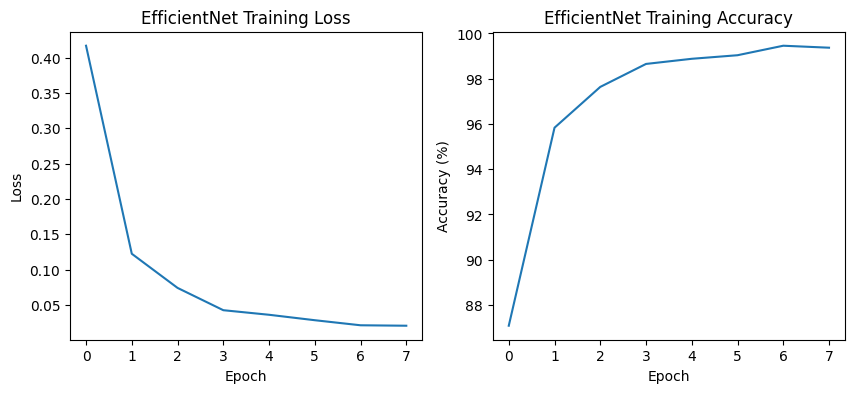

In [21]:
# Ploting the model's loss and accuracy graph
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses_eff)
plt.title("EfficientNet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies_eff)
plt.title("EfficientNet Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()


In [22]:
# Evaluating the model on the test dataset
model_effnet.eval()

correct = 0
total = 0
all_preds_eff = []
all_labels_eff = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_effnet(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds_eff.extend(predicted.cpu().numpy())
        all_labels_eff.extend(labels.cpu().numpy())

test_accuracy_eff = 100 * correct / total
print(f"EfficientNet Test Accuracy: {test_accuracy_eff:.2f}%")


EfficientNet Test Accuracy: 99.77%


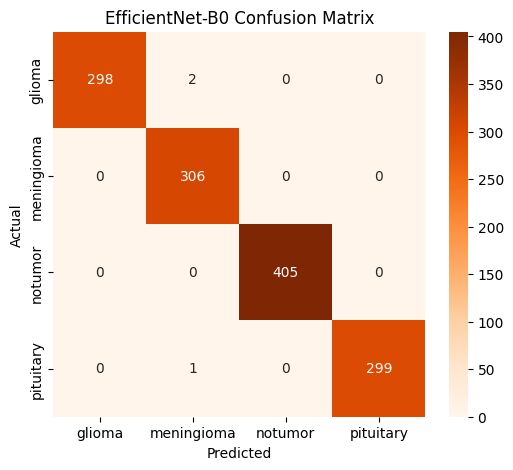

In [25]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm_eff = confusion_matrix(all_labels_eff, all_preds_eff)

plt.figure(figsize=(6,5))
sns.heatmap(cm_eff, annot=True, fmt="d", cmap="Oranges",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()


In [26]:
# Finding tnhe precision, recall and F1-Scores
print(classification_report(
    all_labels_eff,
    all_preds_eff,
    target_names=train_dataset.classes
))


              precision    recall  f1-score   support

      glioma       1.00      0.99      1.00       300
  meningioma       0.99      1.00      1.00       306
     notumor       1.00      1.00      1.00       405
   pituitary       1.00      1.00      1.00       300

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311



In [27]:
#Comparing the results of Both Trained Models
print("MODEL COMPARISON")
print("-------------------------")
print(f"ResNet18 Test Accuracy     : {test_accuracy:.2f}%")
print(f"EfficientNet-B0 Test Accuracy: {test_accuracy_eff:.2f}%")


MODEL COMPARISON
-------------------------
ResNet18 Test Accuracy     : 99.24%
EfficientNet-B0 Test Accuracy: 99.77%


In [28]:
torch.save(model_resnet.state_dict(), "resnet18_brain_tumor.pth")
print('Successfully Done')
torch.save(model_effnet.state_dict(), "efficientnet_b0_brain_tumor.pth")
print('Successfully Done')

Successfully Done
Successfully Done
